# Modul 15 — Causal AI
## Bedah ulang data Modul 5 (Bank Arta Nusantara) dan simulasi selection bias

Notebook ini menjalankan demonstrasi confounder Modul 15 (koefisien naif vs
terkontrol vs kausal sesungguhnya) dan simulasi nyata selection bias pada
data kredit yang disetujui vs ditolak.

## Data dan Demonstrasi Confounder

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
import statsmodels.api as sm

np.random.seed(42)
n = 400
pendapatan_juta = np.clip(np.random.normal(15, 6, n), 4, 60)
usia = np.clip(np.random.normal(38, 9, n), 22, 65).round().astype(int)
lama_kerja = np.clip((usia - 22) * 0.45 + np.random.normal(0, 1.2, n), 0, None)
skor_kredit = np.clip(0.9 * pendapatan_juta + np.random.normal(55, 9, n), 20, 100)
noise = np.random.normal(0, 250, n)
plafon_disetujui_juta = np.clip(80 + pendapatan_juta * 28 + skor_kredit * 4.5 + noise, 50, None)
df = pd.DataFrame({"pendapatan_juta": pendapatan_juta, "usia": usia, "lama_kerja": lama_kerja,
                    "skor_kredit": skor_kredit, "plafon_disetujui_juta": plafon_disetujui_juta})

r, p = stats.pearsonr(df["skor_kredit"], df["plafon_disetujui_juta"])
X_naif = sm.add_constant(df["skor_kredit"])
koef_naif = sm.OLS(df["plafon_disetujui_juta"], X_naif).fit().params["skor_kredit"]
X_kontrol = sm.add_constant(df[["skor_kredit", "pendapatan_juta"]])
koef_kontrol = sm.OLS(df["plafon_disetujui_juta"], X_kontrol).fit().params["skor_kredit"]
koef_benar = 4.5

print(f"Koefisien TANPA kontrol: {koef_naif:.4f}")
print(f"Koefisien DENGAN kontrol: {koef_kontrol:.4f}")
print(f"Koefisien kausal SESUNGGUHNYA: {koef_benar}")

Koefisien TANPA kontrol: 9.8695
Koefisien DENGAN kontrol: 2.3749
Koefisien kausal SESUNGGUHNYA: 4.5


## Visualisasi 1: DAG Confounder dan Perbandingan Koefisien (Asset Baru, mengganti M15-01)

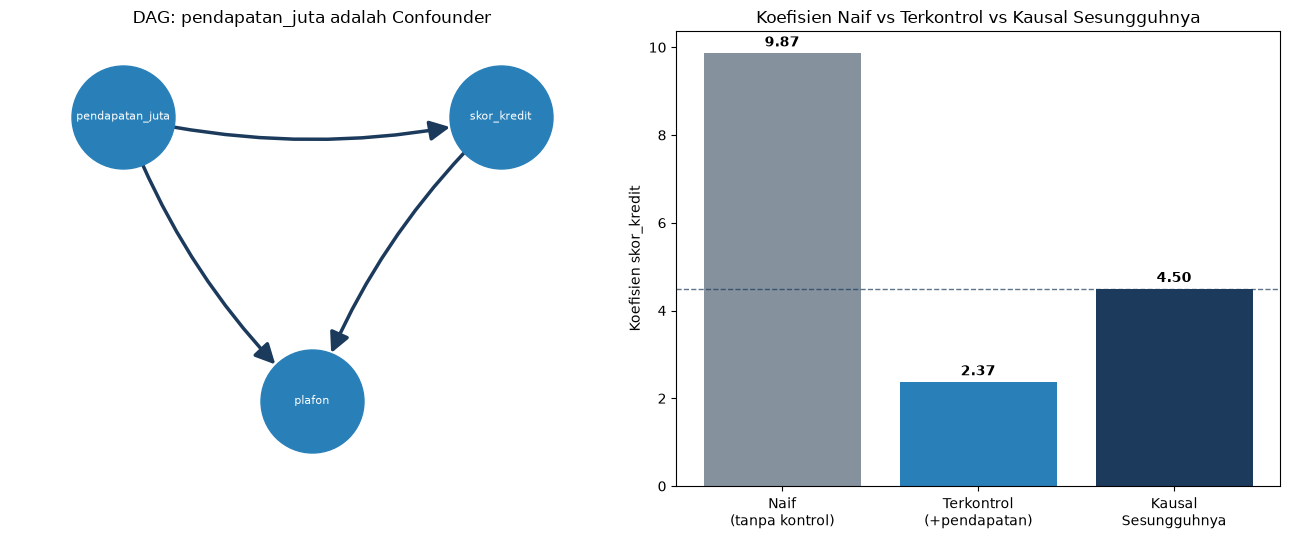

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

G = nx.DiGraph()
G.add_edges_from([("pendapatan_juta", "skor_kredit"), ("pendapatan_juta", "plafon"), ("skor_kredit", "plafon")])
pos = {"pendapatan_juta": (0, 1), "skor_kredit": (1, 1), "plafon": (0.5, 0)}
nx.draw_networkx_nodes(G, pos, node_color="#2980B9", node_size=5500, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white", ax=axes[0])
nx.draw_networkx_edges(G, pos, edge_color="#1B3A5C", arrowsize=30, width=2.5,
                        node_size=5500, arrowstyle="-|>",
                        connectionstyle="arc3,rad=0.12", ax=axes[0])
axes[0].set_title("DAG: pendapatan_juta adalah Confounder")
axes[0].set_xlim(-0.3, 1.3)
axes[0].set_ylim(-0.3, 1.3)
axes[0].axis("off")

nilai = [koef_naif, koef_kontrol, koef_benar]
label = ["Naif\n(tanpa kontrol)", "Terkontrol\n(+pendapatan)", "Kausal\nSesungguhnya"]
warna = ["#C0392B" if abs(v - koef_benar) > 2 else "#2980B9" for v in nilai]
axes[1].bar(label, nilai, color=["#85929E", "#2980B9", "#1B3A5C"])
axes[1].axhline(koef_benar, color="#1B3A5C", linestyle="--", linewidth=1, alpha=0.7)
axes[1].set_ylabel("Koefisien skor_kredit")
axes[1].set_title("Koefisien Naif vs Terkontrol vs Kausal Sesungguhnya")
for i, v in enumerate(nilai):
    axes[1].text(i, v + 0.15, f"{v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("modul15_dag_dan_koefisien.png", dpi=150, bbox_inches="tight")
plt.show()

## Simulasi Selection Bias: Populasi Penuh vs Hanya yang Disetujui

In [3]:
# Simulasi: 2000 PENGAJUAN (bukan cuma yang disetujui), tingkat gagal bayar
# SESUNGGUHNYA bergantung skor_kredit untuk SELURUH populasi pengaju
np.random.seed(7)
n_pop = 2000
skor_kredit_pop = np.clip(np.random.normal(60, 15, n_pop), 10, 100)

# Bank menyetujui HANYA yang skor_kredit >= 50 (aturan internal)
disetujui = skor_kredit_pop >= 50

# Tingkat gagal bayar SESUNGGUHNYA (berlaku utk SEMUA pengaju, termasuk yg ditolak)
logit_pop = -1.5 - 0.04 * (skor_kredit_pop - 60)
prob_gagal_pop = 1 / (1 + np.exp(-logit_pop))
gagal_bayar_pop = np.random.binomial(1, prob_gagal_pop)

tingkat_gagal_populasi_penuh = gagal_bayar_pop.mean()
tingkat_gagal_hanya_disetujui = gagal_bayar_pop[disetujui].mean()
tingkat_gagal_ditolak_seandainya_disetujui = gagal_bayar_pop[~disetujui].mean()

print(f"Total pengajuan: {n_pop}, disetujui: {disetujui.sum()}, ditolak: {(~disetujui).sum()}")
print(f"Tingkat gagal bayar POPULASI PENUH (termasuk yang ditolak): {tingkat_gagal_populasi_penuh:.4f}")
print(f"Tingkat gagal bayar HANYA yang disetujui (yang bank bisa lihat): {tingkat_gagal_hanya_disetujui:.4f}")
print(f"Tingkat gagal bayar seandainya yang DITOLAK tetap disetujui: {tingkat_gagal_ditolak_seandainya_disetujui:.4f}")

Total pengajuan: 2000, disetujui: 1477, ditolak: 523
Tingkat gagal bayar POPULASI PENUH (termasuk yang ditolak): 0.2045
Tingkat gagal bayar HANYA yang disetujui (yang bank bisa lihat): 0.1564
Tingkat gagal bayar seandainya yang DITOLAK tetap disetujui: 0.3403


## Visualisasi 2: Selection Bias, Data yang Bank Bisa Lihat vs Tidak (Asset Baru, mengganti M15-02)

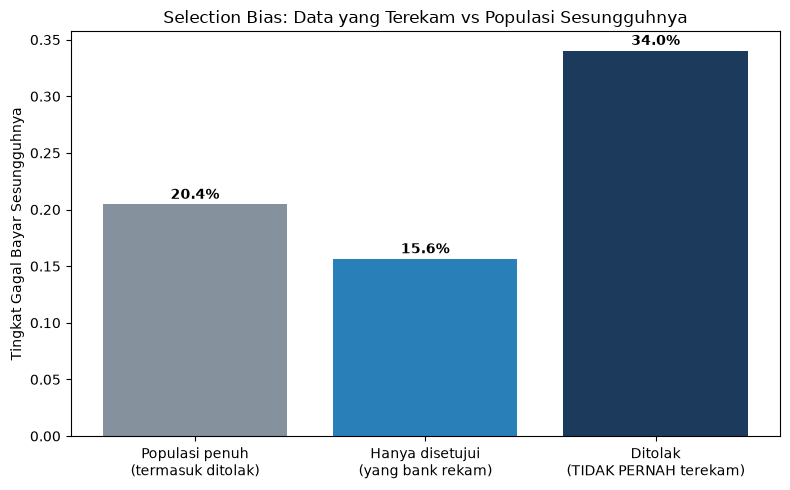

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
kategori = ["Populasi penuh\n(termasuk ditolak)", "Hanya disetujui\n(yang bank rekam)", "Ditolak\n(TIDAK PERNAH terekam)"]
nilai = [tingkat_gagal_populasi_penuh, tingkat_gagal_hanya_disetujui, tingkat_gagal_ditolak_seandainya_disetujui]
warna = ["#85929E", "#2980B9", "#1B3A5C"]
bars = ax.bar(kategori, nilai, color=warna)
ax.set_ylabel("Tingkat Gagal Bayar Sesungguhnya")
ax.set_title("Selection Bias: Data yang Terekam vs Populasi Sesungguhnya")
for i, v in enumerate(nilai):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("modul15_selection_bias.png", dpi=150, bbox_inches="tight")
plt.show()